# **1. Perkenalan Dataset**


# Perkenalan Dataset

Pada proyek ini digunakan dataset **Heart Disease Dataset** yang diperoleh dari Kaggle. Dataset ini berisi berbagai informasi medis pasien yang digunakan untuk memprediksi kemungkinan seseorang mengalami penyakit jantung.

Dataset memiliki total **1048 data** dengan **13 fitur**, seperti usia, jenis kelamin, tekanan darah, kadar kolesterol, detak jantung maksimum, dan beberapa indikator medis lainnya. Target pada dataset ini berupa klasifikasi biner yang menunjukkan ada atau tidaknya penyakit jantung.

Dataset dapat diakses melalui tautan berikut:

https://www.kaggle.com/datasets/winson13/heart-disease-dataset

# **2. Import Library**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import mlflow
import dagshub

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)
from sklearn.model_selection import GridSearchCV

# **3. Memuat Dataset**

In [2]:
df = pd.read_csv("Dataset Heart Disease.csv")

print(df.shape)
print(df.columns)

df.head()

(1048, 13)
Index(['Unnamed: 0', 'age', 'sex', 'chest pain type', 'resting bps',
       'cholesterol', 'fasting blood sugar', 'resting ecg', 'max heart rate',
       'exercise angina', 'oldpeak', 'ST slope', 'target'],
      dtype='object')


,Unnamed: 0,age,sex,chest pain type,resting bps,cholesterol,fasting blood sugar,resting ecg,max heart rate,exercise angina,oldpeak,ST slope,target
0,0,40,1,2,140,289.0,0,0,172,0,0.0,1,0
1,1,49,0,3,160,180.0,0,0,156,0,1.0,2,1
2,2,37,1,2,130,283.0,0,1,98,0,0.0,1,0
3,3,48,0,4,138,214.0,0,0,108,1,1.5,2,1
4,4,54,1,3,150,195.0,0,0,122,0,0.0,1,0


# 4. **Exploratory Data Analysis (EDA)**

Pada tahap ini dilakukan eksplorasi data untuk memahami karakteristik dataset, distribusi fitur, hubungan antar variabel, serta mendeteksi potensi permasalahan seperti missing value, outlier, dan ketidakseimbangan kelas.

Exploratory Data Analysis (EDA) membantu dalam menentukan strategi preprocessing dan pemilihan model machine learning yang tepat.

## 4.1 Informasi Dataset

Tahap awal EDA dilakukan dengan melihat struktur dataset, tipe data, jumlah data, serta ringkasan statistik untuk memahami karakteristik awal data.

In [3]:
print("Shape Dataset:", df.shape)

df.info()

Shape Dataset: (1048, 13)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048 entries, 0 to 1047
Data columns (total 13 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Unnamed: 0           1048 non-null   int64  
 1   age                  1048 non-null   int64  
 2   sex                  1048 non-null   int64  
 3   chest pain type      1048 non-null   int64  
 4   resting bps          1048 non-null   int64  
 5   cholesterol          1048 non-null   float64
 6   fasting blood sugar  1048 non-null   int64  
 7   resting ecg          1048 non-null   int64  
 8   max heart rate       1048 non-null   int64  
 9   exercise angina      1048 non-null   int64  
 10  oldpeak              1048 non-null   float64
 11  ST slope             1048 non-null   int64  
 12  target               1048 non-null   int64  
dtypes: float64(2), int64(11)
memory usage: 106.6 KB


## 4.2 Statistik Deskriptif

Statistik deskriptif digunakan untuk melihat distribusi data numerik seperti rata-rata, nilai minimum, maksimum, dan standar deviasi.

In [4]:
df.describe()

,Unnamed: 0,age,sex,chest pain type,resting bps,cholesterol,fasting blood sugar,resting ecg,max heart rate,exercise angina,oldpeak,ST slope,target
count,1048.000000,1048.000000,1048.000000,1048.000000,1048.000000,1048.000000,1048.000000,1048.000000,1048.000000,1048.000000,1048.000000,1048.000000,1048.000000
mean,390.841603,53.325382,0.734733,2.817748,132.613550,245.172710,0.162214,0.606870,142.918893,0.368321,0.942366,1.532443,0.496183
std,307.916633,9.397822,0.441686,1.118649,17.367605,57.101359,0.368823,0.763313,24.427115,0.482579,1.100429,0.611023,0.500224
min,0.000000,28.000000,0.000000,1.000000,92.000000,85.000000,0.000000,0.000000,69.000000,0.000000,-0.100000,0.000000,0.000000
25%,130.750000,46.000000,0.000000,2.000000,120.000000,208.000000,0.000000,0.000000,125.000000,0.000000,0.000000,1.000000,0.000000
50%,262.000000,54.000000,1.000000,3.000000,130.000000,239.000000,0.000000,0.000000,144.000000,0.000000,0.600000,2.000000,0.000000
75%,657.250000,60.000000,1.000000,4.000000,140.000000,275.000000,0.000000,1.000000,162.000000,1.000000,1.600000,2.000000,1.000000
max,1189.000000,77.000000,1.000000,4.000000,200.000000,603.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,1.000000


## 4.3 Pemeriksaan Missing Value

Pemeriksaan missing value dilakukan untuk memastikan apakah terdapat data yang hilang pada setiap fitur.

In [5]:
missing_values = df.isnull().sum()

missing_values

,0
Unnamed: 0,0
age,0
sex,0
chest pain type,0
resting bps,0
cholesterol,0
fasting blood sugar,0
resting ecg,0
max heart rate,0
exercise angina,0


## 4.4 Distribusi Target

Visualisasi distribusi target dilakukan untuk mengetahui keseimbangan kelas pada dataset.

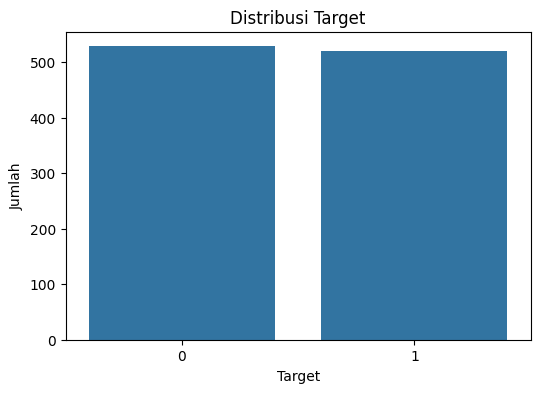

In [6]:
plt.figure(figsize=(6,4))

sns.countplot(x='target', data=df)

plt.title('Distribusi Target')
plt.xlabel('Target')
plt.ylabel('Jumlah')

plt.show()

## 4.5 Distribusi Fitur Numerik

Visualisasi histogram digunakan untuk memahami distribusi masing-masing fitur numerik pada dataset.

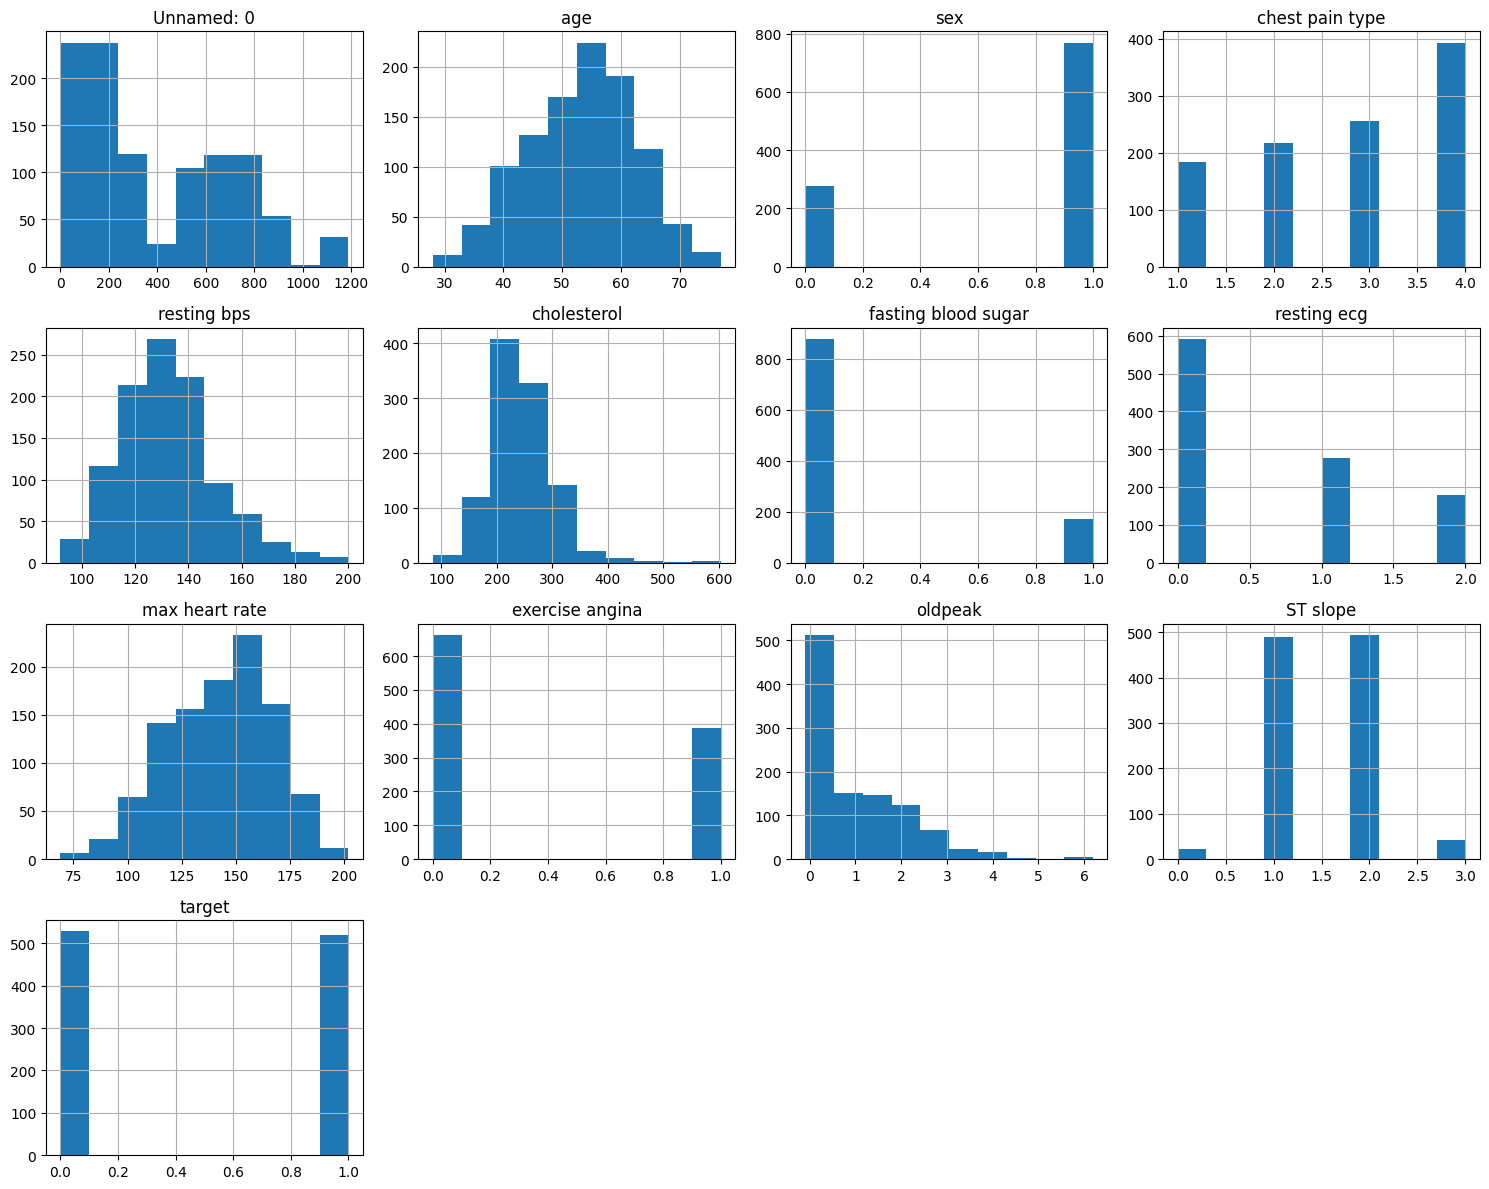

In [7]:
df.hist(figsize=(15,12))

plt.tight_layout()
plt.show()

## 4.6 Korelasi Antar Fitur

Heatmap korelasi digunakan untuk melihat hubungan antar fitur numerik terhadap target maupun antar fitur lainnya.

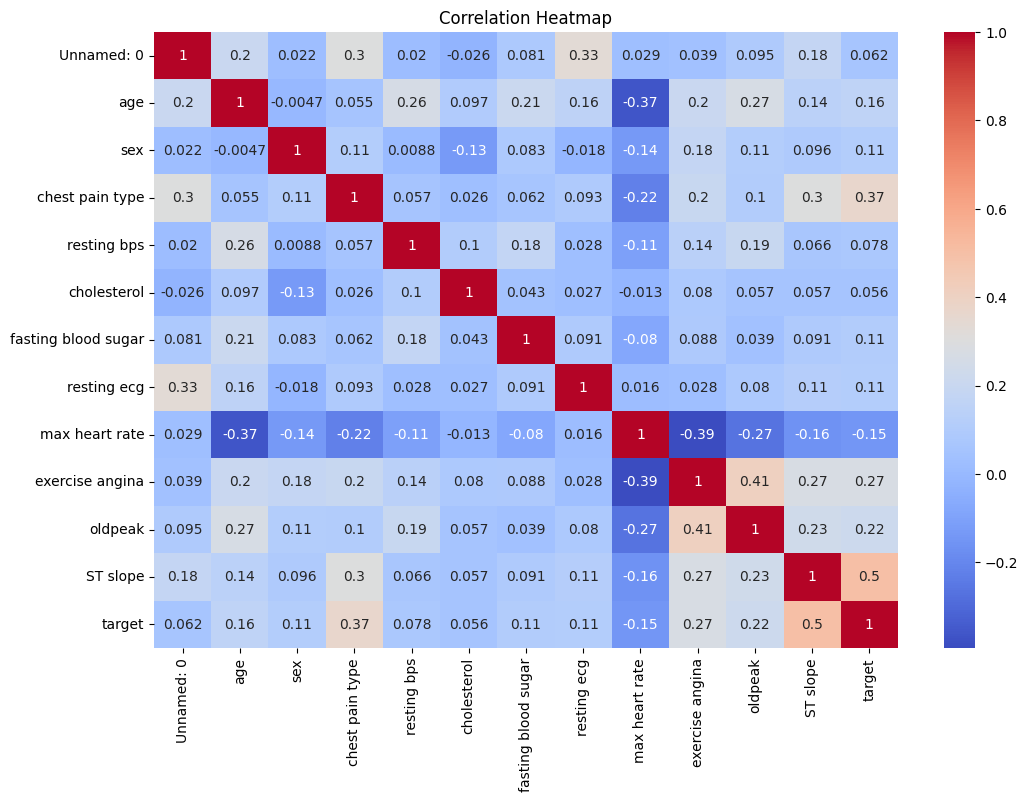

In [8]:
plt.figure(figsize=(12,8))

sns.heatmap(df.corr(), annot=True, cmap='coolwarm')

plt.title('Correlation Heatmap')

plt.show()

## 4.7 Deteksi Outlier

Visualisasi boxplot digunakan untuk mendeteksi kemungkinan adanya outlier pada fitur numerik.

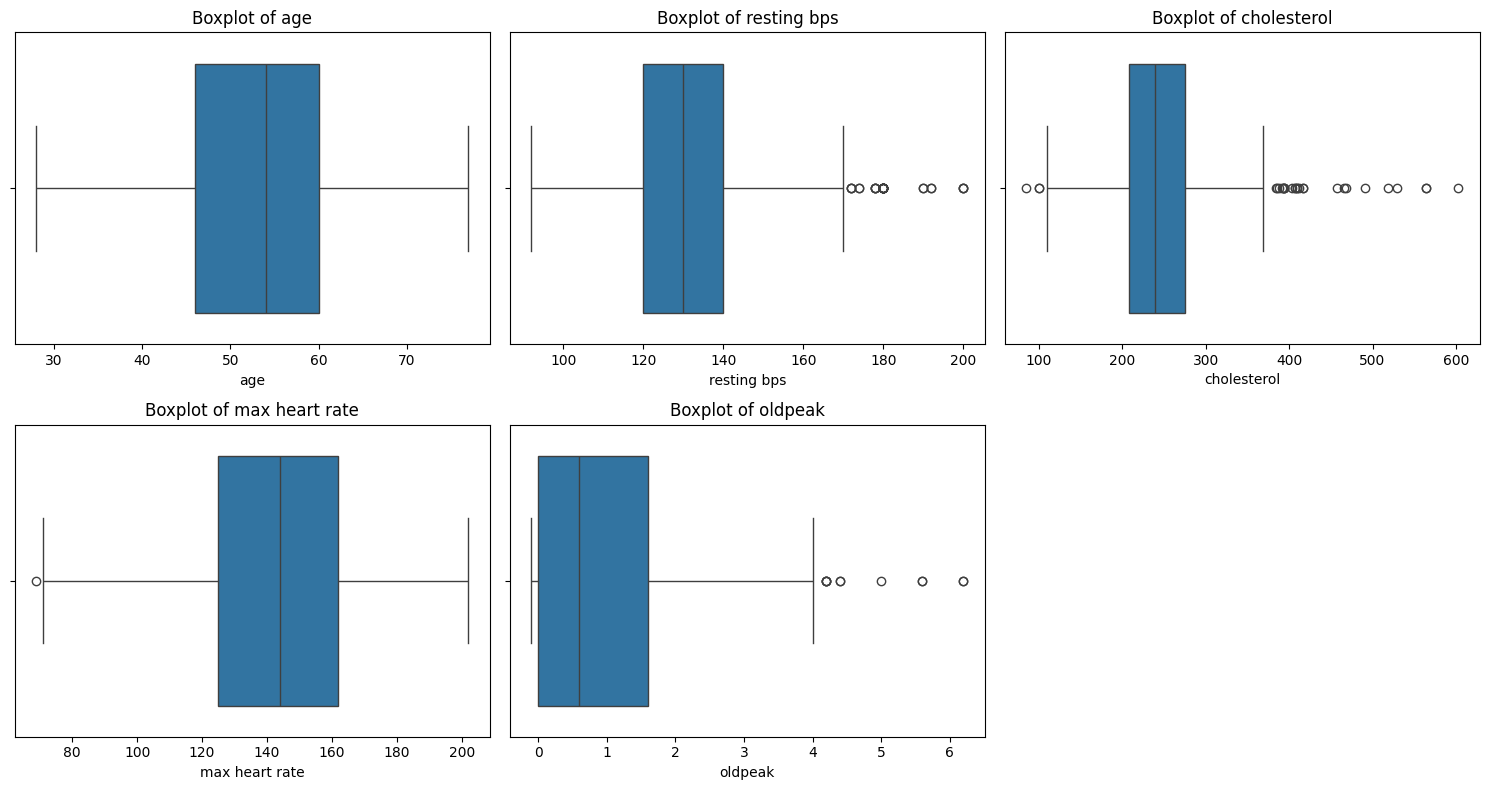

In [9]:
numerical_cols = [
    'age',
    'resting bps',
    'cholesterol',
    'max heart rate',
    'oldpeak'
]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    sns.boxplot(x=df[col], ax=axes[i])
    axes[i].set_title(f'Boxplot of {col}')

# Hapus subplot kosong
fig.delaxes(axes[-1])

plt.tight_layout()
plt.show()

## 4.8 Insight Hasil EDA

Berdasarkan hasil Exploratory Data Analysis (EDA), diperoleh beberapa insight penting sebagai berikut:

1. Dataset terdiri dari 1048 baris dan 13 kolom dengan kombinasi fitur numerik dan kategorikal yang relevan untuk prediksi penyakit jantung.

2. Tidak ditemukan missing value pada dataset sehingga data relatif bersih dan siap digunakan untuk proses preprocessing lebih lanjut.

3. Distribusi target cukup seimbang antara kelas 0 dan 1, sehingga risiko bias model akibat ketidakseimbangan kelas relatif kecil.

4. Beberapa fitur seperti `ST slope`, `chest pain type`, dan `exercise angina` memiliki korelasi cukup kuat terhadap target sehingga berpotensi menjadi fitur penting dalam proses prediksi.

5. Fitur `max heart rate` menunjukkan korelasi negatif terhadap target, yang mengindikasikan bahwa semakin rendah denyut jantung maksimum, semakin tinggi kemungkinan penyakit jantung.

6. Terdapat beberapa outlier pada fitur seperti `cholesterol`, `resting bps`, dan `oldpeak`, namun masih dalam batas yang wajar sehingga akan dipertimbangkan pada tahap preprocessing berikutnya.

7. Sebagian besar fitur sudah berbentuk numerik sehingga memudahkan proses scaling dan pelatihan model machine learning.

# **5. Data Preprocessing**

Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning.

Jika Anda menggunakan data teks, data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.

Berikut adalah tahapan-tahapan yang bisa dilakukan, tetapi **tidak terbatas** pada:
1. Menghapus atau Menangani Data Kosong (Missing Values)
2. Menghapus Data Duplikat
3. Normalisasi atau Standarisasi Fitur
4. Deteksi dan Penanganan Outlier
5. Encoding Data Kategorikal
6. Binning (Pengelompokan Data)

Cukup sesuaikan dengan karakteristik data yang kamu gunakan yah. Khususnya ketika kami menggunakan data tidak terstruktur.

## 5.1 Feature Selection

Pada tahap ini dilakukan pemilihan fitur yang akan digunakan untuk proses pelatihan model. Kolom yang tidak relevan seperti index atau identifier akan dihapus karena tidak memberikan kontribusi terhadap prediksi.

In [10]:
df = df.drop(columns=['Unnamed: 0'])

df.head()

,age,sex,chest pain type,resting bps,cholesterol,fasting blood sugar,resting ecg,max heart rate,exercise angina,oldpeak,ST slope,target
0,40,1,2,140,289.0,0,0,172,0,0.0,1,0
1,49,0,3,160,180.0,0,0,156,0,1.0,2,1
2,37,1,2,130,283.0,0,1,98,0,0.0,1,0
3,48,0,4,138,214.0,0,0,108,1,1.5,2,1
4,54,1,3,150,195.0,0,0,122,0,0.0,1,0


## 5.2 Memisahkan Feature dan Target

Dataset dipisahkan menjadi fitur (X) dan target (y) untuk mempersiapkan proses pelatihan model machine learning.

In [11]:
X = df.drop('target', axis=1)
y = df['target']

print("Shape X:", X.shape)
print("Shape y:", y.shape)

Shape X: (1048, 11)
Shape y: (1048,)


## 5.3 Train-Test Split

Data dibagi menjadi data latih dan data uji untuk mengevaluasi performa model terhadap data yang belum pernah dilihat sebelumnya.

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (838, 11)
X_test : (210, 11)
y_train: (838,)
y_test : (210,)


## 5.4 Feature Scaling

Feature scaling dilakukan menggunakan StandardScaler untuk menstandarkan rentang nilai fitur numerik agar proses pelatihan model menjadi lebih optimal.

In [13]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## 5.5 Konversi ke DataFrame

In [14]:
X_train_scaled = pd.DataFrame(
    X_train_scaled,
    columns=X.columns
)

X_test_scaled = pd.DataFrame(
    X_test_scaled,
    columns=X.columns
)

X_train_scaled.head()

,age,sex,chest pain type,resting bps,cholesterol,fasting blood sugar,resting ecg,max heart rate,exercise angina,oldpeak,ST slope
0,0.372160,0.611368,-1.629001,-0.193592,-2.059436,-0.445932,0.521824,-1.130868,1.308424,0.230322,-0.861096
1,-0.274650,0.611368,0.164827,0.093948,-1.543350,-0.445932,-0.787423,0.296526,-0.764278,0.947497,0.760473
2,0.156557,0.611368,-0.732087,0.669028,1.410793,-0.445932,-0.787423,0.500440,-0.764278,-0.845440,-0.861096
3,0.479962,-1.635677,-1.629001,-0.193592,-0.884897,-0.445932,0.521824,-0.478345,-0.764278,-0.307559,-0.861096
4,-1.029262,0.611368,1.061741,-1.343753,-0.884897,-0.445932,1.831071,1.397659,-0.764278,-0.845440,-0.861096


## 5.5 Menyimpan Dataset Hasil Preprocessing

Dataset hasil preprocessing disimpan agar dapat digunakan kembali pada tahap pelatihan model dan automation pipeline.

In [15]:
os.makedirs('data_processed', exist_ok=True)

X_train_scaled.to_csv('data_processed/X_train.csv', index=False)
X_test_scaled.to_csv('data_processed/X_test.csv', index=False)

y_train.to_csv('data_processed/y_train.csv', index=False)
y_test.to_csv('data_processed/y_test.csv', index=False)

In [16]:
import os

print(os.listdir('data_processed'))

['X_test.csv', 'X_train.csv', 'y_test.csv', 'y_train.csv']


# **6. Modelling**
Pada tahap ini dilakukan pelatihan dan evaluasi beberapa algoritma machine learning untuk menentukan model terbaik dalam memprediksi penyakit jantung.

## 6.1 Pelatihan Model

Beberapa algoritma machine learning digunakan untuk membandingkan performa model pada dataset yang telah dipreprocessing.

In [17]:
models = {
    "Logistic Regression": LogisticRegression(),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42)
}

results = []

for name, model in models.items():

    model.fit(X_train_scaled, y_train)

    y_pred = model.predict(X_test_scaled)

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    results.append({
        "Model": name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-Score": f1
    })

results_df = pd.DataFrame(results)

results_df

,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.790476,0.788462,0.788462,0.788462
1,Decision Tree,0.738095,0.763441,0.682692,0.720812
2,Random Forest,0.833333,0.834951,0.826923,0.830918


## 6.2 Perbandingan Performa Model

Visualisasi dilakukan untuk membandingkan performa setiap model berdasarkan nilai accuracy.

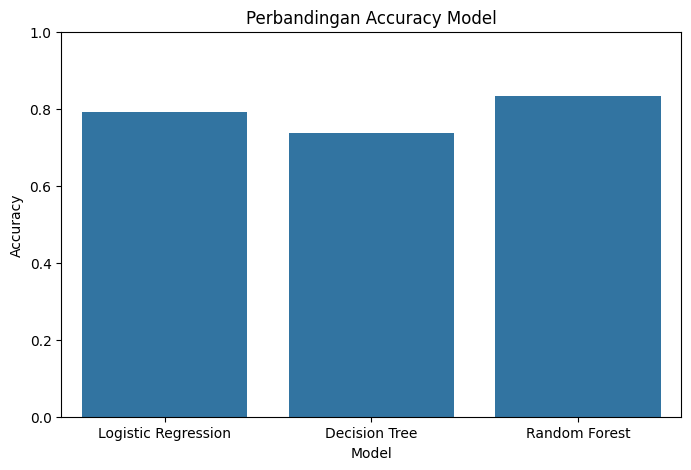

In [18]:
plt.figure(figsize=(8,5))

sns.barplot(
    x='Model',
    y='Accuracy',
    data=results_df
)

plt.title('Perbandingan Accuracy Model')

plt.ylim(0,1)

plt.show()

## 6.3 Pemilihan Model Terbaik

Model terbaik dipilih berdasarkan performa evaluasi pada data testing.

In [19]:
best_model = RandomForestClassifier(random_state=42)

best_model.fit(X_train_scaled, y_train)

y_pred = best_model.predict(X_test_scaled)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.83      0.84      0.84       106
           1       0.83      0.83      0.83       104

    accuracy                           0.83       210
   macro avg       0.83      0.83      0.83       210
weighted avg       0.83      0.83      0.83       210



## 6.4 Confusion Matrix

Confusion matrix digunakan untuk melihat performa klasifikasi model terhadap masing-masing kelas.

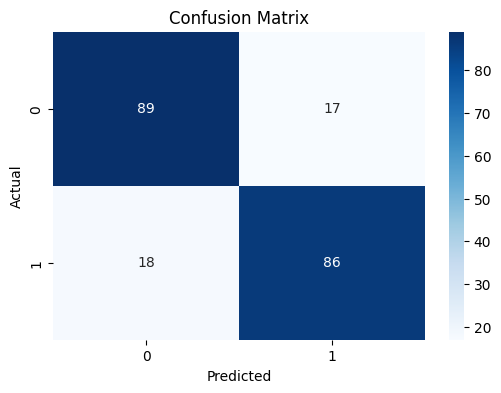

In [20]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.show()

## 6.5 Feature Importance

Feature importance digunakan untuk mengetahui fitur yang paling berpengaruh terhadap prediksi model.

In [21]:
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': best_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

feature_importance

,Feature,Importance
10,ST slope,0.254503
7,max heart rate,0.114418
0,age,0.108865
2,chest pain type,0.106031
4,cholesterol,0.105609
9,oldpeak,0.100965
3,resting bps,0.094277
6,resting ecg,0.043237
8,exercise angina,0.034887
1,sex,0.024838


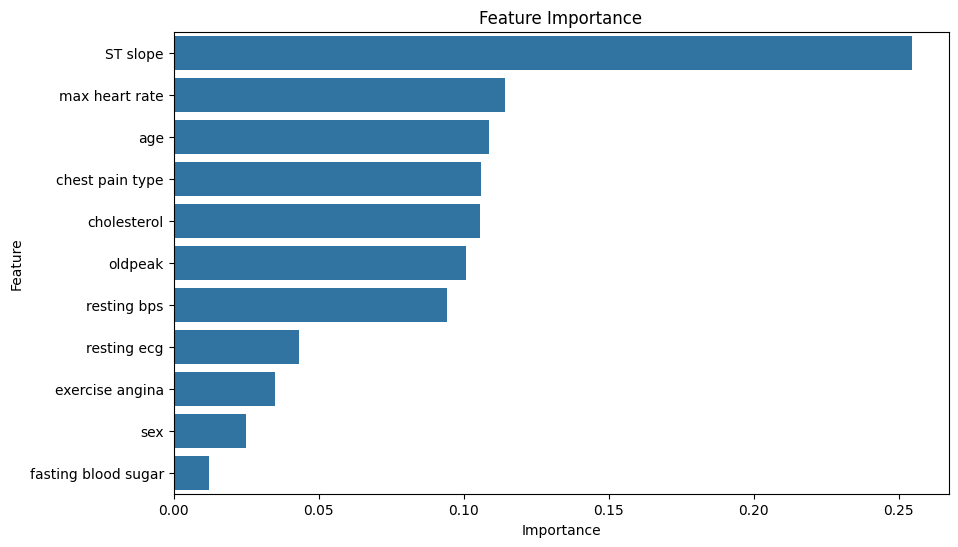

In [22]:
plt.figure(figsize=(10,6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=feature_importance
)

plt.title('Feature Importance')

plt.show()

# 7. Hyperparameter Tuning

Pada tahap ini dilakukan tuning hyperparameter untuk meningkatkan performa model terbaik yang diperoleh dari tahap modelling sebelumnya.

## 7.1 Menentukan Hyperparameter

GridSearchCV digunakan untuk mencari kombinasi hyperparameter terbaik pada model Random Forest.

In [23]:
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

In [24]:
grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid_search.fit(X_train_scaled, y_train)

GridSearchCV(cv=5, estimator=RandomForestClassifier(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [5, 10, None], 'min_samples_leaf': [1, 2],
                         'min_samples_split': [2, 5],
                         'n_estimators': [100, 200]},
             scoring='accuracy')

## 7.2 Hyperparameter Terbaik

Setelah proses tuning selesai, diperoleh kombinasi hyperparameter terbaik berdasarkan performa accuracy tertinggi.

In [25]:
print("Best Parameters:")
print(grid_search.best_params_)

print("\nBest Score:")
print(grid_search.best_score_)

Best Parameters:
{'max_depth': 5, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 200}

Best Score:
0.7970772740233819


In [26]:
best_rf = grid_search.best_estimator_

y_pred_tuned = best_rf.predict(X_test_scaled)

print(classification_report(y_test, y_pred_tuned))

              precision    recall  f1-score   support

           0       0.83      0.78      0.81       106
           1       0.79      0.84      0.81       104

    accuracy                           0.81       210
   macro avg       0.81      0.81      0.81       210
weighted avg       0.81      0.81      0.81       210



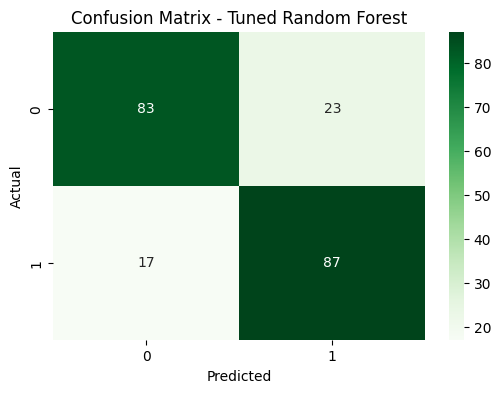

In [27]:
cm_tuned = confusion_matrix(y_test, y_pred_tuned)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm_tuned,
    annot=True,
    fmt='d',
    cmap='Greens'
)

plt.title('Confusion Matrix - Tuned Random Forest')

plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.show()

In [28]:
feature_importance_tuned = pd.DataFrame({
    'Feature': X.columns,
    'Importance': best_rf.feature_importances_
})

feature_importance_tuned = feature_importance_tuned.sort_values(
    by='Importance',
    ascending=False
)

feature_importance_tuned

,Feature,Importance
10,ST slope,0.427157
2,chest pain type,0.168808
9,oldpeak,0.089760
7,max heart rate,0.065758
0,age,0.055717
8,exercise angina,0.049982
3,resting bps,0.042364
4,cholesterol,0.042015
6,resting ecg,0.034074
1,sex,0.017058


Berdasarkan hasil tuning menggunakan GridSearchCV, diperoleh kombinasi hyperparameter terbaik pada model Random Forest dengan parameter:

- max_depth = 5
- min_samples_leaf = 2
- min_samples_split = 2
- n_estimators = 200

Meskipun performa accuracy setelah tuning sedikit lebih rendah dibanding model default, model hasil tuning cenderung lebih stabil dan memiliki generalisasi yang lebih baik terhadap data baru.

In [29]:
!pip install mlflow==2.19.0 dagshub

In [30]:
dagshub.auth.add_app_token("73ee1c8bdf530db6ad85bc2b25f10673d7d1ee6e")

In [31]:
dagshub.init(
    repo_owner="xebec51",
    repo_name="mlsystem-heart-disease-rinaldi",
    mlflow=True
)

mlflow.set_experiment("Heart Disease Prediction")

Accessing as xebec51

Repository mlsystem-heart-disease-rinaldi doesn't exist, creating it under current user.

Initialized MLflow to track repo "xebec51/mlsystem-heart-disease-rinaldi"

Repository xebec51/mlsystem-heart-disease-rinaldi initialized!

2026/05/10 06:01:33 INFO mlflow.tracking.fluent: Experiment with name 'Heart Disease Prediction' does not exist. Creating a new experiment.


<Experiment: artifact_location='mlflow-artifacts:/0809b1ae73b0458d8a20571533d2ea55', creation_time=1778392893008, experiment_id='0', last_update_time=1778392893008, lifecycle_stage='active', name='Heart Disease Prediction', tags={}>